In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

df = pd.read_csv('../data/df-no-passes.csv')

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
scores = cross_val_score(lr_model, X_train, y_train, cv=10, scoring='neg_root_mean_squared_error')
rmse_cv = -scores.mean()

print(f'Средняя цена дома: {np.expm1(df['SalePrice'].mean()):.0f} ')
print(f'Ошибка модели на {(rmse_cv * 100):.2f} % от стоимости дома')


Средняя цена дома: 166717 
Ошибка модели на 18.33 % от стоимости дома


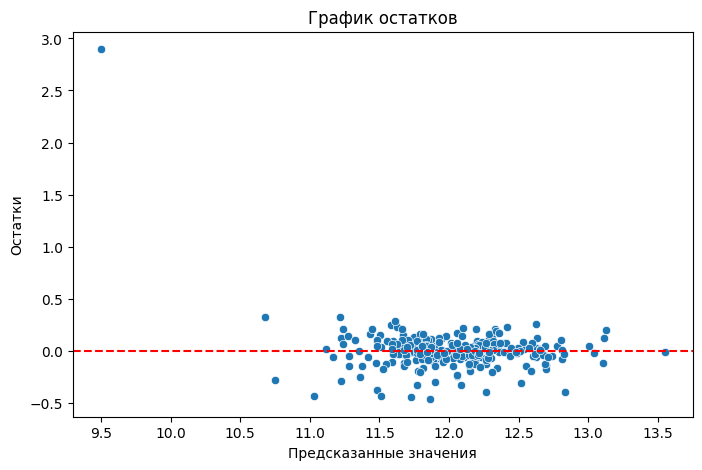

In [18]:
lr_model.fit(X_train, y_train)
lr_predicted = lr_model.predict(X_test)

residuals = y_test.values - lr_predicted

plt.figure(figsize=(8, 5))
sns.scatterplot(x=lr_predicted, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.show()